In [5]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 25.5 MB/s  0:00:00m0:00:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


### Enviroment Set Up

This notebook sets up a lightweight **Natural Language Processing (NLP)** environment for named-entity analysis and visualization.

- **spaCy**: core NLP library used to process text and extract entities  
- **en_core_web_sm**: English language model used by spaCy  
- **pandas**: tabular storage and summary of extracted entities  
- **matplotlib** and **seaborn**: plotting libraries used to visualize entity distributions  

In the next code cell, these libraries are imported so the notebook can load the NLP model, analyze text, and create charts.

In [6]:
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Basic Entitiy Recognition
In the next code cell, we perform **basic named entity recognition (NER)** using spaCy.

The workflow is:

- load the English NLP model with `spacy.load("en_core_web_sm")`
- define a short sample passage about **Apple, Tim Cook, Cupertino, California, money, and dates**
- process the text with the NLP pipeline
- extract the detected named entities from `doc.ents`
- print each entity along with:
    - the original entity text
    - its entity label
    - a human-readable explanation of that label

This gives a quick first look at how spaCy identifies important real-world references such as **organizations, people, locations, dates, and monetary values** in unstructured text.

In [7]:
nlp = spacy.load("en_core_web_sm")
text = """
Apple Inc. CEO Tim Cook announced new AI features for iPhones at their headquarters 
in Cupertino, California yesterday. The company plans to invest $10 billion in AI 
research over the next 5 years, starting from January 2025.
"""
doc = nlp(text)
print("Named Entities:")
for ent in doc.ents:
    print(f"Text: {ent.text:<30} Label: {ent.label_:<10} Description: {spacy.explain(ent.label_)}")

Named Entities:
Text: Apple Inc.                     Label: ORG        Description: Companies, agencies, institutions, etc.
Text: Tim Cook                       Label: PERSON     Description: People, including fictional
Text: AI                             Label: ORG        Description: Companies, agencies, institutions, etc.
Text: iPhones                        Label: ORG        Description: Companies, agencies, institutions, etc.
Text: Cupertino                      Label: GPE        Description: Countries, cities, states
Text: California                     Label: GPE        Description: Countries, cities, states
Text: yesterday                      Label: DATE       Description: Absolute or relative dates or periods
Text: $10 billion                    Label: MONEY      Description: Monetary values, including unit
Text: AI                             Label: GPE        Description: Countries, cities, states
Text: the next 5 years               Label: DATE       Description: Absolute

### Advanced Entity Analysis
In the next cell, the workflow moves from **printing entities** to a **reusable analysis pipeline**.

- It defines `analyze_entities(text)` so entity extraction can be run on any input text, not just one hardcoded example.
- It converts `doc.ents` into a structured `DataFrame` (`Entity`, `Label`, `Description`) for easier inspection, filtering, and downstream analysis.
- It computes `label_counts` with `value_counts()`, giving a quantitative summary of entity types.
- It returns both detailed and aggregated outputs (`df`, `label_counts`) so later cells can directly visualize results.

This is an improvement over the previous cell because that cell only prints entities line-by-line, while this one produces **structured, reusable, and analysis-ready data**.

In [8]:
def analyze_entities(text):
    doc = nlp(text)
    
    # Create a DataFrame of entities
    entities = [(ent.text, ent.label_, spacy.explain(ent.label_)) 
               for ent in doc.ents]
    
    df = pd.DataFrame(entities, columns=['Entity', 'Label', 'Description'])
    
    # Get entity counts
    label_counts = df['Label'].value_counts()
    
    return df, label_counts

# Analyze text
df_entities, entity_counts = analyze_entities(text)

print("\nEntity Analysis Summary:")
print(df_entities)
print("\nEntity Type Counts:")
print(entity_counts)



Entity Analysis Summary:
              Entity   Label                              Description
0         Apple Inc.     ORG  Companies, agencies, institutions, etc.
1           Tim Cook  PERSON              People, including fictional
2                 AI     ORG  Companies, agencies, institutions, etc.
3            iPhones     ORG  Companies, agencies, institutions, etc.
4          Cupertino     GPE                Countries, cities, states
5         California     GPE                Countries, cities, states
6          yesterday    DATE    Absolute or relative dates or periods
7        $10 billion   MONEY          Monetary values, including unit
8                 AI     GPE                Countries, cities, states
9   the next 5 years    DATE    Absolute or relative dates or periods
10      January 2025    DATE    Absolute or relative dates or periods

Entity Type Counts:
Label
ORG       3
GPE       3
DATE      3
PERSON    1
MONEY     1
Name: count, dtype: int64


###  Visualization of Entity Distribution

In the next cell, the `entity_counts` summary is visualized as a **bar chart** to show how frequently each named-entity type appears in the text.

- `plot_entity_distribution(entity_counts)` creates a figure and uses **Seaborn** to plot:
    - **x-axis:** entity labels (`ORG`, `GPE`, `DATE`, `PERSON`, `MONEY`)
    - **y-axis:** count of each label
- A title and axis labels are added for readability.
- Numeric count labels are placed above each bar so exact values are visible without estimation.
- X-axis tick labels are rotated to prevent overlap.
- `tight_layout()` improves spacing, and `show()` renders the final chart.

This provides a quick visual comparison of which entity categories are most and least common in the analyzed passage.

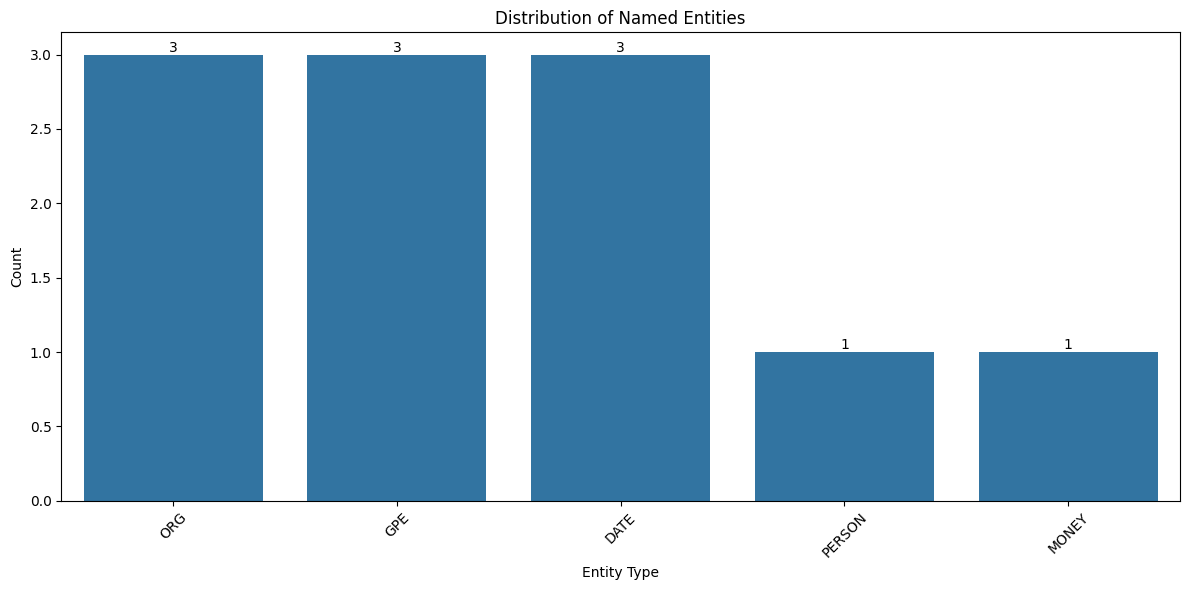

In [9]:
def plot_entity_distribution(entity_counts):
    plt.figure(figsize=(12, 6))
    sns.barplot(x=entity_counts.index, y=entity_counts.values)
    plt.title('Distribution of Named Entities')
    plt.xlabel('Entity Type')
    plt.ylabel('Count')
    
    # Add value labels on top of bars
    for i, v in enumerate(entity_counts.values):
        plt.text(i, v, str(v), ha='center', va='bottom')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_entity_distribution(entity_counts)

### 5 Entity Context Analysis
In the next code cell, the analysis is extended from **entity labels** to each entity’s **local textual context**.

- `analyze_entity_context(doc, window=2)` is defined to inspect entities in a processed spaCy document.
- For every entity in `doc.ents`, the function:
	- computes a token window around the entity (`2` tokens before and after by default),
	- safely clips boundaries with `max(0, ...)` and `min(len(doc), ...)`,
	- extracts the surrounding phrase as context text.
- Each result is stored as a dictionary with:
	- `Entity` (entity text),
	- `Type` (entity label),
	- `Context` (nearby words).
- The list of dictionaries is converted into a pandas `DataFrame` and returned.

After defining the function, the cell runs it on `nlp(text)`, stores the output in `context_df`, and prints the context table to show how each detected entity appears in sentence-level usage.


In [10]:
def analyze_entity_context(doc, window=2):
    context_info = []
    
    for ent in doc.ents:
        # Get token indices for the entity
        start = max(0, ent.start - window)
        end = min(len(doc), ent.end + window)
        
        # Get context words
        context = doc[start:end].text
        
        context_info.append({
            'Entity': ent.text,
            'Type': ent.label_,
            'Context': context
        })
    
    return pd.DataFrame(context_info)

# Analyze context
context_df = analyze_entity_context(nlp(text))
print("\nEntity Context Analysis:")
print(context_df)



Entity Context Analysis:
              Entity    Type                                   Context
0         Apple Inc.     ORG                      \nApple Inc. CEO Tim
1           Tim Cook  PERSON           Inc. CEO Tim Cook announced new
2                 AI     ORG             announced new AI features for
3            iPhones     ORG             features for iPhones at their
4          Cupertino     GPE                \nin Cupertino, California
5         California     GPE          Cupertino, California yesterday.
6          yesterday    DATE               , California yesterday. The
7        $10 billion   MONEY               to invest $10 billion in AI
8                 AI     GPE                  billion in AI \nresearch
9   the next 5 years    DATE  research over the next 5 years, starting
10      January 2025    DATE             starting from January 2025.\n


### Custom Entity Pattern Recognition

Sometimes the default spaCy model does not recognize **domain-specific terms** or may assign labels that do not match the analysis goal. A **custom pattern** lets us define exact words or phrases that should always be tagged in a specific way.

In the next code cell, an `EntityRuler` is added to the pipeline so we can:

- detect terms the pretrained model may miss
- assign **custom labels** such as `PRODUCT` and `TECH`
- improve consistency for repeated keywords
- compare default NER results with rule-based entity matches

Here, custom patterns are used so terms like **“iPhone”** and **“AI”** can be recognized with labels that better match the intended interpretation of the text.

In [11]:
# Add custom patterns for entity recognition
ruler = nlp.add_pipe("entity_ruler", before="ner")
patterns = [
    {"label": "PRODUCT", "pattern": "iPhone"},
    {"label": "TECH", "pattern": "AI"}
]
ruler.add_patterns(patterns)

# Process text with custom patterns
doc_custom = nlp(text)
print("\nEntities with Custom Patterns:")
for ent in doc_custom.ents:
    print(f"{ent.text:<20} {ent.label_:<10}")



Entities with Custom Patterns:
Apple Inc.           ORG       
Tim Cook             PERSON    
AI                   TECH      
iPhones              ORG       
Cupertino            GPE       
California           GPE       
yesterday            DATE      
$10 billion          MONEY     
AI                   TECH      
the next 5 years     DATE      
January 2025         DATE      


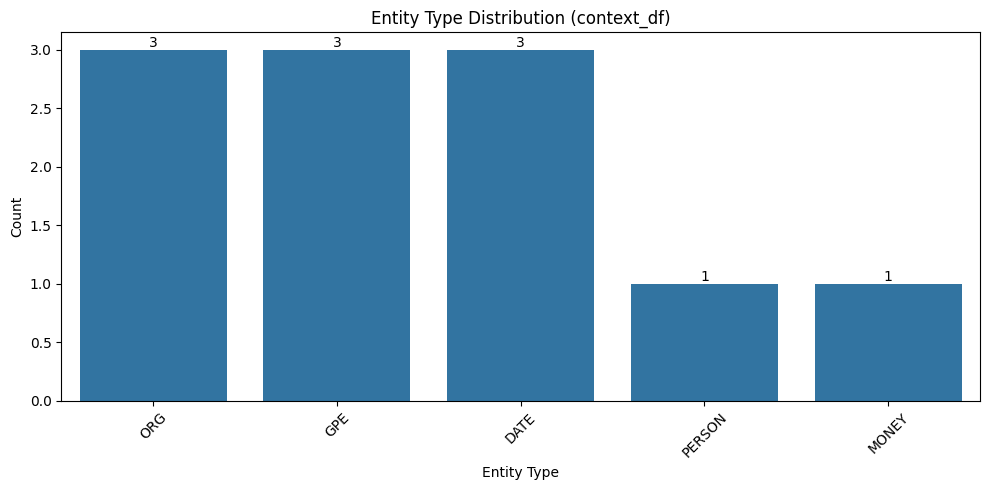

In [12]:
# Graph the "new" dataframe (context_df): entity type distribution
type_counts = context_df["Type"].value_counts()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=type_counts.index, y=type_counts.values)
plt.title("Entity Type Distribution (context_df)")
plt.xlabel("Entity Type")
plt.ylabel("Count")

for i, v in enumerate(type_counts.values):
	ax.text(i, v, str(v), ha="center", va="bottom")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()